# IoT Radio Fingerprinting – Environment & Node Classification

**Project:** Identifying Deployment Environments and IoT Sensor Nodes Using Link Quality Fluctuations  
**Institution:** TU Dresden, MSc Nanoelectronic Systems  
**Radio:** IEEE 802.15.4 (Adafruit Feather nRF52840)

- **Scenario I** – Classify the deployment *environment* (5 classes: bridge, garden, forest, river, lake)  
- **Scenario II** – Classify the sensor *node* (3 classes: A, B, C)

Each scenario uses two train/test strategies:
1. **Strategy 1:** Random 75/25 split from the same dataset  
2. **Strategy 2:** Train on 4 environments, test on the held-out 5th


In [15]:
# Cell 1 – Imports and reproducibility
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             ConfusionMatrixDisplay)
from torchinfo import summary

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Using device: {device}")


Using device: cuda


In [16]:
# Cell 2 – Load all 15 CSV files
DATA_DIR = "./data_folder"

all_frames = []
for fpath in sorted(glob.glob(os.path.join(DATA_DIR, "*.csv"))):
    fname = os.path.basename(fpath)
    parts = fname.split("_")
    node = parts[0][-1]       # A, B, or C
    env  = parts[1]           # bridge, forest, ...

    df = pd.read_csv(fpath)
    df["node"] = node
    df["environment"] = env
    all_frames.append(df)

data = pd.concat(all_frames, ignore_index=True)
print(f"Total rows:   {len(data):,}")
print(f"Nodes:        {sorted(data['node'].unique())}")
print(f"Environments: {sorted(data['environment'].unique())}")
print(f"NaN RSSI:     {data['rssi'].isna().sum()} ({data['rssi'].isna().mean()*100:.2f}%)")
data.head()


Total rows:   270,000
Nodes:        ['A', 'B', 'C']
Environments: ['bridge', 'forest', 'garden', 'lake', 'river']
NaN RSSI:     1409 (0.52%)


,timestamp,node_id,rssi,lqi,node,environment
0,2026-03-11 03:00:00.000,nodeA,-65.772260,215,A,bridge
1,2026-03-11 03:00:00.100,nodeA,-69.654140,186,A,bridge
2,2026-03-11 03:00:00.200,nodeA,-69.771500,240,A,bridge
3,2026-03-11 03:00:00.300,nodeA,-70.177956,192,A,bridge
4,2026-03-11 03:00:00.400,nodeA,-67.598930,192,A,bridge


In [17]:
# Cell 3 – Preprocessing functions
# As specified in the project description:
#   1. Differentiate: y_i = x_{i+1} - x_i
#   2. Normalise to [0,1]: z_i = (y_i - y_min) / (y_max - y_min)
#   3. Segment into overlapping frames

def clean_and_differentiate(rssi_series):
    """Interpolate NaN gaps, then compute y[i] = x[i+1] - x[i]."""
    s = pd.Series(rssi_series).interpolate(method="linear").bfill().ffill()
    return np.diff(s.values)

def normalise(y):
    """Min-max normalise to [0, 1]."""
    y_min, y_max = y.min(), y.max()
    if y_max - y_min < 1e-10:
        return np.full_like(y, 0.5, dtype=np.float32)
    return ((y - y_min) / (y_max - y_min)).astype(np.float32)

def segment_frames(signal, frame_size, overlap_frac):
    """Segment into overlapping frames."""
    step = int(frame_size * (1 - overlap_frac))
    frames = []
    for start in range(0, len(signal) - frame_size + 1, step):
        frames.append(signal[start : start + frame_size])
    return np.array(frames, dtype=np.float32)

# Sanity check
demo = np.array([-60, np.nan, -61, -63, -65, -64, -60, -58, -59, -61], dtype=float)
d = clean_and_differentiate(demo)
n = normalise(d)
print("Raw:          ", demo)
print("Differentiated:", np.round(d, 2))
print("Normalised:   ", np.round(n, 3))


Raw:           [-60.  nan -61. -63. -65. -64. -60. -58. -59. -61.]
Differentiated: [-0.5 -0.5 -2.  -2.   1.   4.   2.  -1.  -2. ]
Normalised:    [0.25  0.25  0.    0.    0.5   1.    0.667 0.167 0.   ]


In [18]:
# Cell 4 – Preprocess all series: differentiate then normalise each

series_dict = {}   # key = (node, env), value = normalised diff array

for (node, env), grp in data.groupby(["node", "environment"]):
    rssi = grp.sort_values("timestamp")["rssi"].values
    diff = clean_and_differentiate(rssi)
    norm = normalise(diff)
    series_dict[(node, env)] = norm

print(f"Built {len(series_dict)} preprocessed series (3 nodes x 5 environments)")
for k, v in sorted(series_dict.items()):
    print(f"  {k}: {len(v):,} samples, range=[{v.min():.3f}, {v.max():.3f}]")


Built 15 preprocessed series (3 nodes x 5 environments)
  ('A', 'bridge'): 17,999 samples, range=[0.000, 1.000]
  ('A', 'forest'): 17,999 samples, range=[0.000, 1.000]
  ('A', 'garden'): 17,999 samples, range=[0.000, 1.000]
  ('A', 'lake'): 17,999 samples, range=[0.000, 1.000]
  ('A', 'river'): 17,999 samples, range=[0.000, 1.000]
  ('B', 'bridge'): 17,999 samples, range=[0.000, 1.000]
  ('B', 'forest'): 17,999 samples, range=[0.000, 1.000]
  ('B', 'garden'): 17,999 samples, range=[0.000, 1.000]
  ('B', 'lake'): 17,999 samples, range=[0.000, 1.000]
  ('B', 'river'): 17,999 samples, range=[0.000, 1.000]
  ('C', 'bridge'): 17,999 samples, range=[0.000, 1.000]
  ('C', 'forest'): 17,999 samples, range=[0.000, 1.000]
  ('C', 'garden'): 17,999 samples, range=[0.000, 1.000]
  ('C', 'lake'): 17,999 samples, range=[0.000, 1.000]
  ('C', 'river'): 17,999 samples, range=[0.000, 1.000]


In [19]:
# Cell 5 – Dataset builder

ENVS  = sorted(data["environment"].unique())
NODES = sorted(data["node"].unique())
ENV2IDX  = {e: i for i, e in enumerate(ENVS)}
NODE2IDX = {n: i for i, n in enumerate(NODES)}

print(f"Environment labels: {ENV2IDX}")
print(f"Node labels:        {NODE2IDX}")

def build_dataset(scenario, frame_size, overlap):
    X_all, y_all, groups = [], [], []

    if scenario == "env":
        # Scenario I: mix all nodes within each environment
        for env in ENVS:
            combined = np.concatenate([series_dict[(n, env)] for n in NODES])
            frames = segment_frames(combined, frame_size, overlap)
            X_all.append(frames)
            y_all.append(np.full(len(frames), ENV2IDX[env], dtype=np.int64))
            groups.extend([env] * len(frames))

    elif scenario == "node":
        # Scenario II: mix all environments within each node
        for node in NODES:
            for env in ENVS:
                frames = segment_frames(series_dict[(node, env)], frame_size, overlap)
                X_all.append(frames)
                y_all.append(np.full(len(frames), NODE2IDX[node], dtype=np.int64))
                groups.extend([env] * len(frames))

    X = np.concatenate(X_all)[:, np.newaxis, :]   # (N, 1, frame_size)
    y = np.concatenate(y_all)
    return X, y, np.array(groups)

# Verify with project-specified frame sizes: 500 and 1000
for scn, label in [("env", "I (Environment, 5-class)"), ("node", "II (Node, 3-class)")]:
    for fs in [500, 1000]:
        X, y, g = build_dataset(scn, fs, 0.5)
        print(f"  Scenario {label}, frame={fs}: X={X.shape}, classes={np.unique(y)}")


Environment labels: {'bridge': 0, 'forest': 1, 'garden': 2, 'lake': 3, 'river': 4}
Node labels:        {'A': 0, 'B': 1, 'C': 2}
  Scenario I (Environment, 5-class), frame=500: X=(1070, 1, 500), classes=[0 1 2 3 4]
  Scenario I (Environment, 5-class), frame=1000: X=(530, 1, 1000), classes=[0 1 2 3 4]
  Scenario II (Node, 3-class), frame=500: X=(1050, 1, 500), classes=[0 1 2]
  Scenario II (Node, 3-class), frame=1000: X=(510, 1, 1000), classes=[0 1 2]


In [20]:
# Cell 6 – Model definitions

class CNN1D(nn.Module):
    def __init__(self, n_classes, frame_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.BatchNorm1d(channels), nn.ReLU(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)


class ResNet1D(nn.Module):
    def __init__(self, n_classes, frame_size):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.res_blocks = nn.Sequential(
            ResBlock(64), ResBlock(64), ResBlock(64),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.head(self.res_blocks(self.stem(x)))


print("CNN1D summary (5-class, frame=500):")
summary(CNN1D(5, 500), input_size=(1, 1, 500), verbose=1)
print("\nResNet1D summary (5-class, frame=500):")
summary(ResNet1D(5, 500), input_size=(1, 1, 500), verbose=1)


CNN1D summary (5-class, frame=500):
Layer (type:depth-idx)                   Output Shape              Param #
CNN1D                                    [1, 5]                    --
├─Sequential: 1-1                        [1, 128, 1]               --
│    └─Conv1d: 2-1                       [1, 32, 500]              256
│    └─BatchNorm1d: 2-2                  [1, 32, 500]              64
│    └─ReLU: 2-3                         [1, 32, 500]              --
│    └─MaxPool1d: 2-4                    [1, 32, 250]              --
│    └─Conv1d: 2-5                       [1, 64, 250]              10,304
│    └─BatchNorm1d: 2-6                  [1, 64, 250]              128
│    └─ReLU: 2-7                         [1, 64, 250]              --
│    └─MaxPool1d: 2-8                    [1, 64, 125]              --
│    └─Conv1d: 2-9                       [1, 128, 125]             24,704
│    └─BatchNorm1d: 2-10                 [1, 128, 125]             256
│    └─ReLU: 2-11                     

Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D                                 [1, 5]                    --
├─Sequential: 1-1                        [1, 64, 250]              --
│    └─Conv1d: 2-1                       [1, 64, 500]              512
│    └─BatchNorm1d: 2-2                  [1, 64, 500]              128
│    └─ReLU: 2-3                         [1, 64, 500]              --
│    └─MaxPool1d: 2-4                    [1, 64, 250]              --
├─Sequential: 1-2                        [1, 64, 250]              --
│    └─ResBlock: 2-5                     [1, 64, 250]              --
│    │    └─Sequential: 3-1              [1, 64, 250]              24,960
│    │    └─ReLU: 3-2                    [1, 64, 250]              --
│    └─ResBlock: 2-6                     [1, 64, 250]              --
│    │    └─Sequential: 3-3              [1, 64, 250]              24,960
│    │    └─ReLU: 3-4                    [1, 64, 250]              --
│    

In [21]:
# Cell 7 – Training and evaluation utilities

def make_loaders(X_train, y_train, X_test, y_test, batch_size=64):
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))
    g = torch.Generator().manual_seed(SEED)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g),
            DataLoader(test_ds,  batch_size=batch_size))

def train_model(model, train_loader, epochs=60, lr=1e-3, verbose=True,
                test_loader=None, n_classes=None):
    """Train with Adam + weight decay + cosine annealing LR.
    If test_loader is provided, tracks train/test loss and accuracy per epoch.
    Returns a history dict.
    """
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = loss_fn(out, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            n += len(xb)
        scheduler.step()

        train_loss = total_loss / n
        train_acc = correct / n
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # Test evaluation (if provided)
        if test_loader is not None:
            model.eval()
            t_loss, t_correct, t_n = 0.0, 0, 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    out = model(xb)
                    t_loss += loss_fn(out, yb).item() * len(xb)
                    t_correct += (out.argmax(1) == yb).sum().item()
                    t_n += len(xb)
            history["test_loss"].append(t_loss / t_n)
            history["test_acc"].append(t_correct / t_n)

        if verbose and (epoch + 1) % 15 == 0:
            msg = f"    Epoch {epoch+1:3d}/{epochs}  loss={train_loss:.4f}  acc={train_acc:.3f}"
            if test_loader is not None:
                msg += f"  | val_loss={history['test_loss'][-1]:.4f}  val_acc={history['test_acc'][-1]:.3f}"
            msg += f"  lr={opt.param_groups[0]['lr']:.2e}"
            print(msg)

    return history

def evaluate(model, test_loader, n_classes):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(device)).argmax(1).cpu())
            all_true.append(yb)
    y_true = torch.cat(all_true).numpy()
    y_pred = torch.cat(all_preds).numpy()
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    return acc, cm, y_true, y_pred

print("Utilities ready.")


Utilities ready.


In [22]:
# Cell 8 – Run all 32 experiments
# 2 scenarios x 2 strategies x 2 frame sizes x 2 overlaps x 2 models = 32
# Frame sizes: 500 and 1000 (as specified in the project description)

FRAME_SIZES = [500, 1000]
OVERLAPS    = [0.4, 0.5]
SCENARIOS   = [("env", 5, ENVS, "I (Environment)"),
               ("node", 3, NODES, "II (Node)")]
MODEL_DEFS  = [("CNN1D", CNN1D), ("ResNet1D", ResNet1D)]
EPOCHS      = 100

results = []
cm_store = {}
history_store = {}   # training curves for Strategy 1

for scenario_key, n_classes, label_names, scenario_label in SCENARIOS:
    for frame_size in FRAME_SIZES:
        for overlap in OVERLAPS:
            X, y, groups = build_dataset(scenario_key, frame_size, overlap)
            unique_groups = sorted(set(groups))

            for model_name, ModelClass in MODEL_DEFS:

                # ── Strategy 1: 75/25 split ──
                set_seed(SEED)
                X_tr, X_te, y_tr, y_te = train_test_split(
                    X, y, test_size=0.25, random_state=SEED, stratify=y)
                train_ld, test_ld = make_loaders(X_tr, y_tr, X_te, y_te)

                print(f"\n{'='*70}")
                print(f"  Train: {len(X_tr)}, Test: {len(X_te)}")

                set_seed(SEED)
                model = ModelClass(n_classes, frame_size)
                hist = train_model(model, train_ld, epochs=EPOCHS,
                                   test_loader=test_ld, n_classes=n_classes)
                acc, cm, _, _ = evaluate(model, test_ld, n_classes)

                # Store training history for plotting
                hist_key = (model_name, scenario_label, frame_size, overlap)
                history_store[hist_key] = hist

                print(f"  >> {model_name} | Strategy 1 (Seen) | Scenario {scenario_label} "
                      f"| frame={frame_size} | overlap={int(overlap*100)}% "
                      f"| Accuracy: {acc*100:.1f}%")

                results.append(dict(
                    Model=model_name, Scenario=scenario_label,
                    Strategy="1 (Seen)", Frame=frame_size,
                    Overlap=f"{int(overlap*100)}%", Accuracy=round(acc*100, 1)))
                cm_store[(model_name, scenario_label, "1 (Seen)",
                          frame_size, overlap)] = (cm, label_names, acc)

                # ── Strategy 2: leave-one-environment-out ──
                fold_accs, all_yt, all_yp = [], [], []
                for fold_idx, held_out in enumerate(unique_groups):
                    mask_test  = groups == held_out
                    mask_train = ~mask_test
                    X_tr2, y_tr2 = X[mask_train], y[mask_train]
                    X_te2, y_te2 = X[mask_test],  y[mask_test]

                    if len(X_te2) == 0:
                        continue

                    set_seed(SEED + fold_idx)
                    tr2, te2 = make_loaders(X_tr2, y_tr2, X_te2, y_te2)
                    m = ModelClass(n_classes, frame_size)
                    _ = train_model(m, tr2, epochs=EPOCHS, verbose=False)
                    a, _, yt2, yp2 = evaluate(m, te2, n_classes)
                    fold_accs.append(a)
                    all_yt.append(yt2); all_yp.append(yp2)

                mean_acc = np.mean(fold_accs) if fold_accs else 0.0
                agg_cm = (confusion_matrix(np.concatenate(all_yt),
                                           np.concatenate(all_yp),
                                           labels=range(n_classes))
                          if all_yt else np.zeros((n_classes, n_classes), dtype=int))

                print(f"  Fold accuracies: {[f'{a:.3f}' for a in fold_accs]}")
                print(f"  >> {model_name} | Strategy 2 (Unseen) | Scenario {scenario_label} "
                      f"| frame={frame_size} | overlap={int(overlap*100)}% "
                      f"| Accuracy: {mean_acc*100:.1f}%")

                results.append(dict(
                    Model=model_name, Scenario=scenario_label,
                    Strategy="2 (Unseen)", Frame=frame_size,
                    Overlap=f"{int(overlap*100)}%", Accuracy=round(mean_acc*100, 1)))
                cm_store[(model_name, scenario_label, "2 (Unseen)",
                          frame_size, overlap)] = (agg_cm, label_names, mean_acc)

print(f"\n{'='*70}")
print(f"All 32 experiments complete. {len(cm_store)} confusion matrices stored.")



  Train: 671, Test: 224
    Epoch  15/100  loss=0.4569  acc=0.854  | val_loss=0.5927  val_acc=0.790  lr=9.46e-04
    Epoch  30/100  loss=0.2224  acc=0.928  | val_loss=2.4798  val_acc=0.513  lr=7.94e-04
    Epoch  45/100  loss=0.1401  acc=0.960  | val_loss=4.5912  val_acc=0.469  lr=5.78e-04
    Epoch  60/100  loss=0.0461  acc=0.997  | val_loss=0.6604  val_acc=0.750  lr=3.45e-04
    Epoch  75/100  loss=0.0397  acc=0.997  | val_loss=0.4187  val_acc=0.830  lr=1.46e-04
    Epoch  90/100  loss=0.0271  acc=1.000  | val_loss=0.3284  val_acc=0.897  lr=2.45e-05
  >> CNN1D | Strategy 1 (Seen) | Scenario I (Environment) | frame=500 | overlap=40% | Accuracy: 90.2%
  Fold accuracies: ['0.000', '0.000', '0.000', '0.000', '0.000']
  >> CNN1D | Strategy 2 (Unseen) | Scenario I (Environment) | frame=500 | overlap=40% | Accuracy: 0.0%

  Train: 671, Test: 224
    Epoch  15/100  loss=0.3962  acc=0.854  | val_loss=1.7047  val_acc=0.491  lr=9.46e-04
    Epoch  30/100  loss=0.1890  acc=0.946  | val_loss=4.4

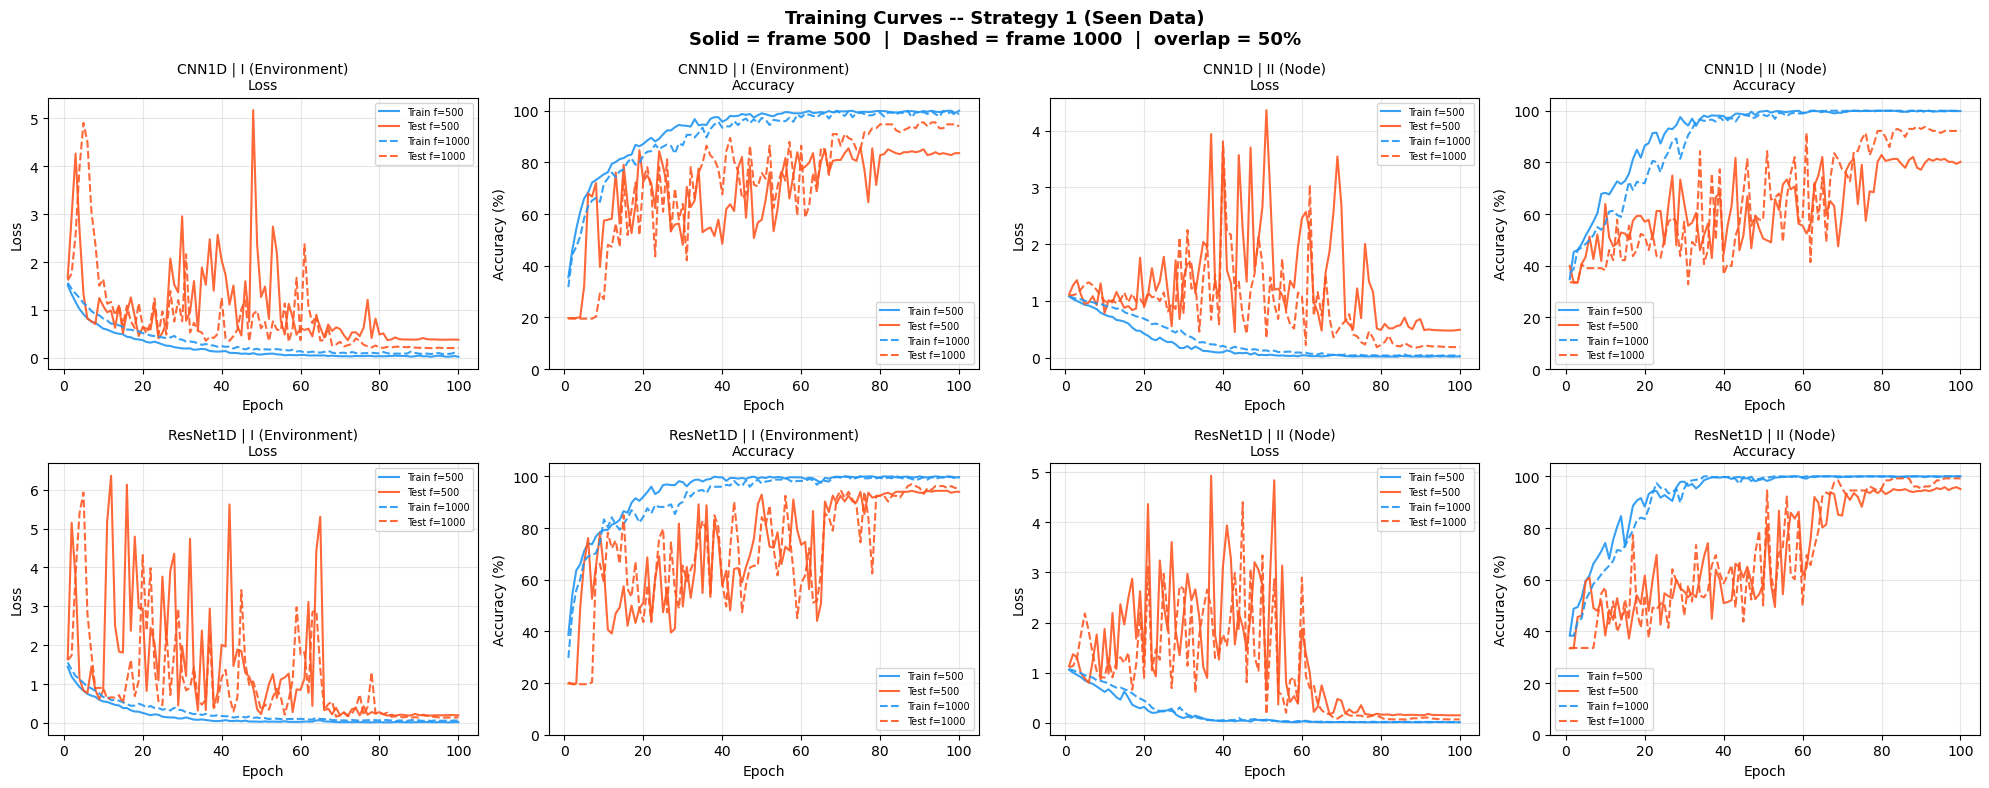

Saved -> training_curves.png


In [23]:
# Cell 8b – Training curves: Loss and Accuracy per epoch (Strategy 1)
#           2x2 grid: Model x Scenario. Solid=frame500, Dashed=frame1000

combos = [
    ("CNN1D",    "I (Environment)"),
    ("CNN1D",    "II (Node)"),
    ("ResNet1D", "I (Environment)"),
    ("ResNet1D", "II (Node)"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Training Curves -- Strategy 1 (Seen Data)\n"
             "Solid = frame 500  |  Dashed = frame 1000  |  overlap = 50%",
             fontsize=13, fontweight="bold")

for idx, (mname, scn) in enumerate(combos):
    row = idx // 2
    col_base = (idx % 2) * 2

    ax_loss = axes[row][col_base]
    ax_acc  = axes[row][col_base + 1]
    title = f"{mname} | {scn}"

    for fs, ls in [(500, "-"), (1000, "--")]:
        key = (mname, scn, fs, 0.5)
        if key not in history_store:
            continue
        hist = history_store[key]
        ep = range(1, len(hist["train_loss"]) + 1)

        ax_loss.plot(ep, hist["train_loss"], ls, color="#2196F3",
                     label=f"Train f={fs}", alpha=0.9)
        if hist["test_loss"]:
            ax_loss.plot(ep, hist["test_loss"], ls, color="#FF5722",
                         label=f"Test f={fs}", alpha=0.9)

        ax_acc.plot(ep, [a*100 for a in hist["train_acc"]], ls,
                    color="#2196F3", label=f"Train f={fs}", alpha=0.9)
        if hist["test_acc"]:
            ax_acc.plot(ep, [a*100 for a in hist["test_acc"]], ls,
                        color="#FF5722", label=f"Test f={fs}", alpha=0.9)

    ax_loss.set_title(f"{title}\nLoss", fontsize=10)
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=7); ax_loss.grid(True, alpha=0.3)

    ax_acc.set_title(f"{title}\nAccuracy", fontsize=10)
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.legend(fontsize=7); ax_acc.grid(True, alpha=0.3)
    ax_acc.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> training_curves.png")


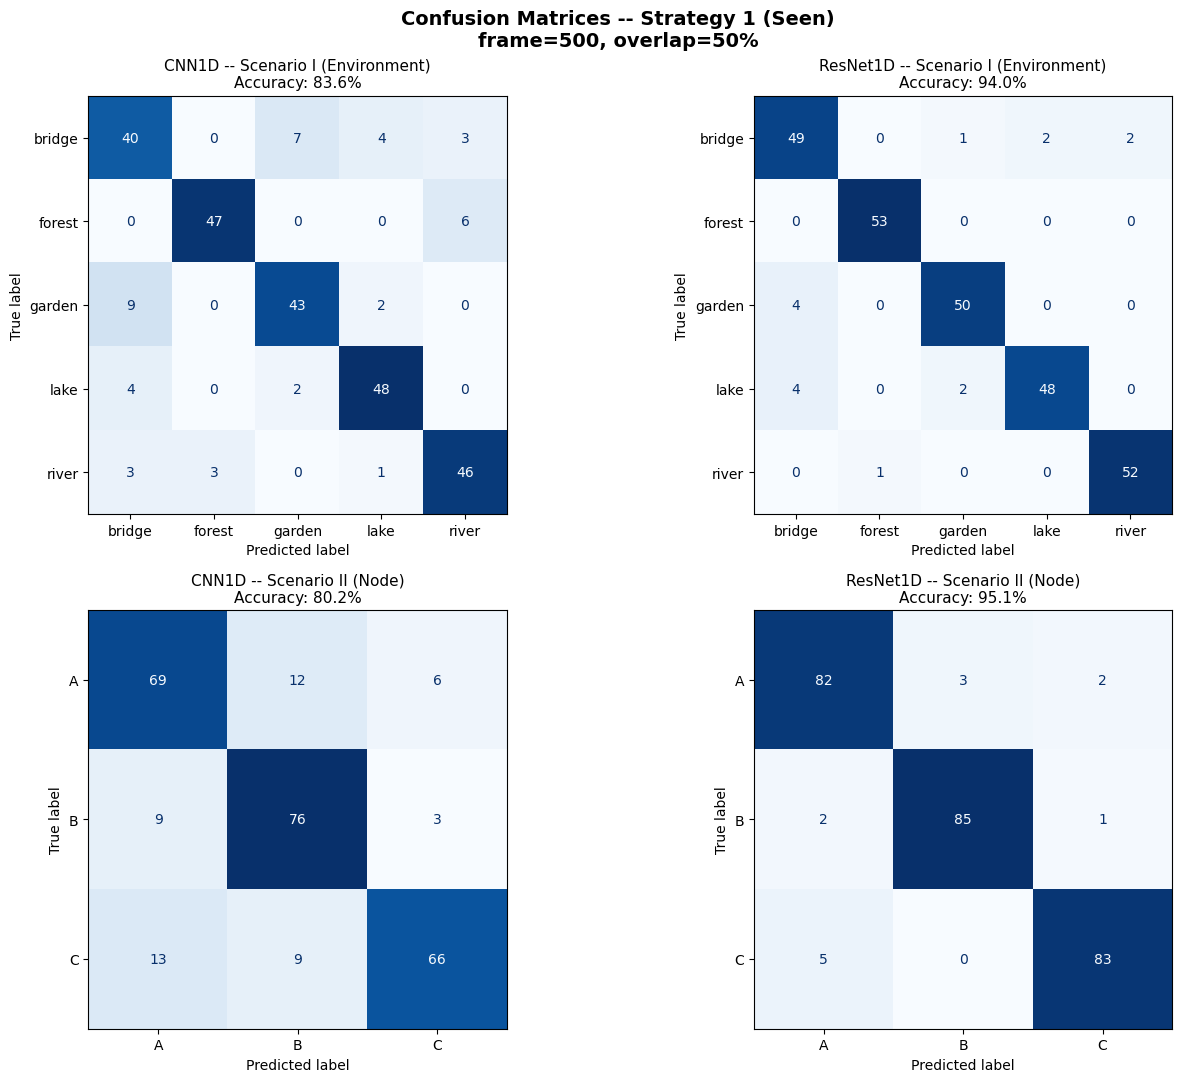

Saved -> confusion_matrices_strategy1_f500.png


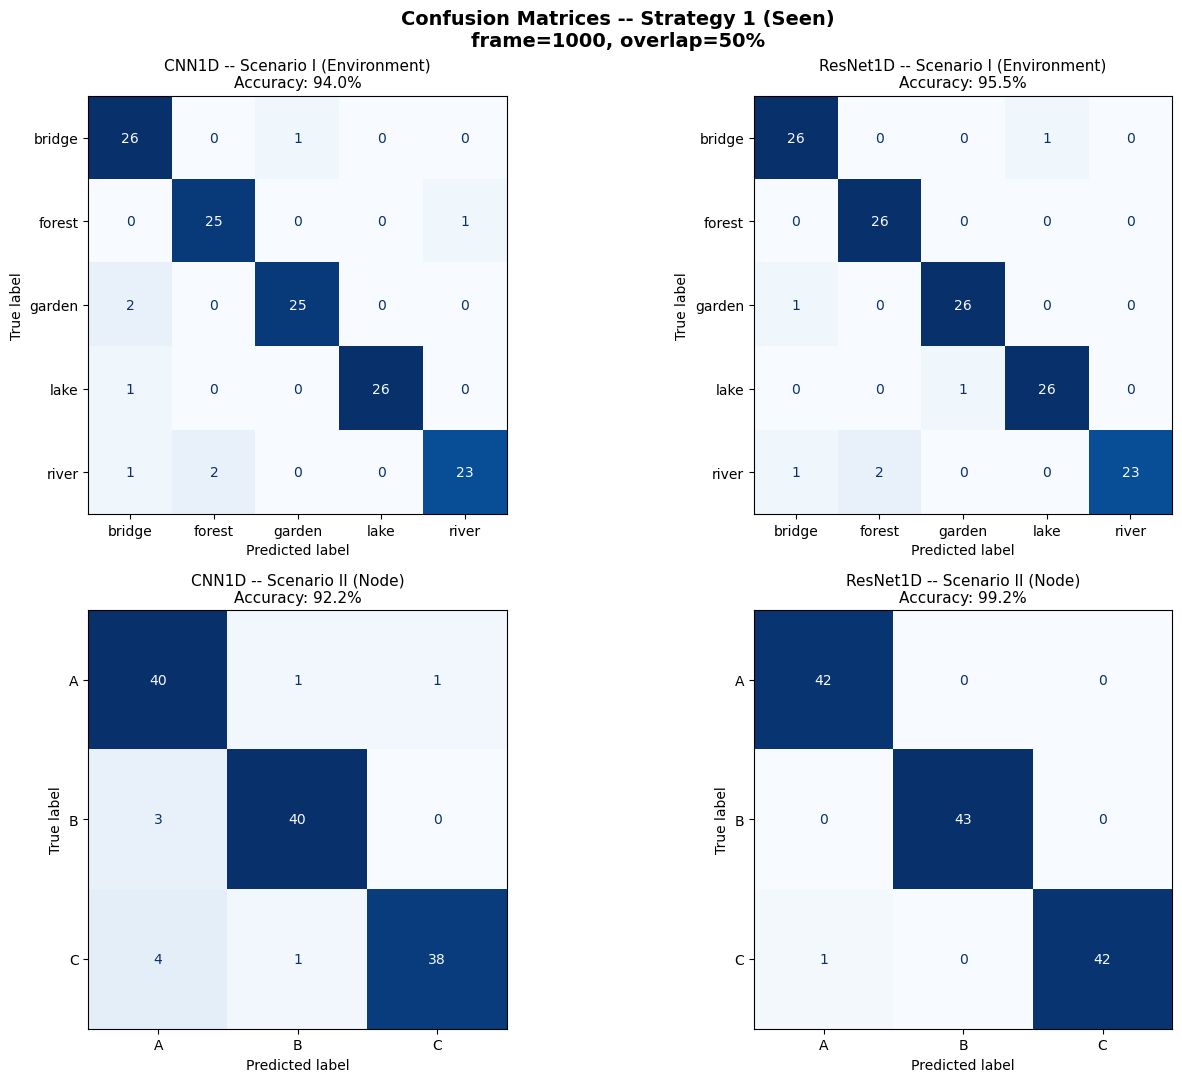

Saved -> confusion_matrices_strategy1_f1000.png


In [24]:
# Cell 9 – Confusion matrices: Strategy 1 (Seen), BOTH frame sizes

plot_configs = [
    (0, 0, "CNN1D",    "I (Environment)"),
    (0, 1, "ResNet1D", "I (Environment)"),
    (1, 0, "CNN1D",    "II (Node)"),
    (1, 1, "ResNet1D", "II (Node)"),
]

for fs in [500, 1000]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"Confusion Matrices -- Strategy 1 (Seen)\n"
                 f"frame={fs}, overlap=50%", fontsize=14, fontweight="bold")

    for row, col, mname, scn_label in plot_configs:
        cm, labels, acc = cm_store[(mname, scn_label, "1 (Seen)", fs, 0.5)]
        ax = axes[row][col]
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(
            ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{mname} -- Scenario {scn_label}\n"
                     f"Accuracy: {acc*100:.1f}%", fontsize=11)

    plt.tight_layout()
    plt.savefig(f"confusion_matrices_strategy1_f{fs}.png", dpi=150)
    plt.show()
    print(f"Saved -> confusion_matrices_strategy1_f{fs}.png")


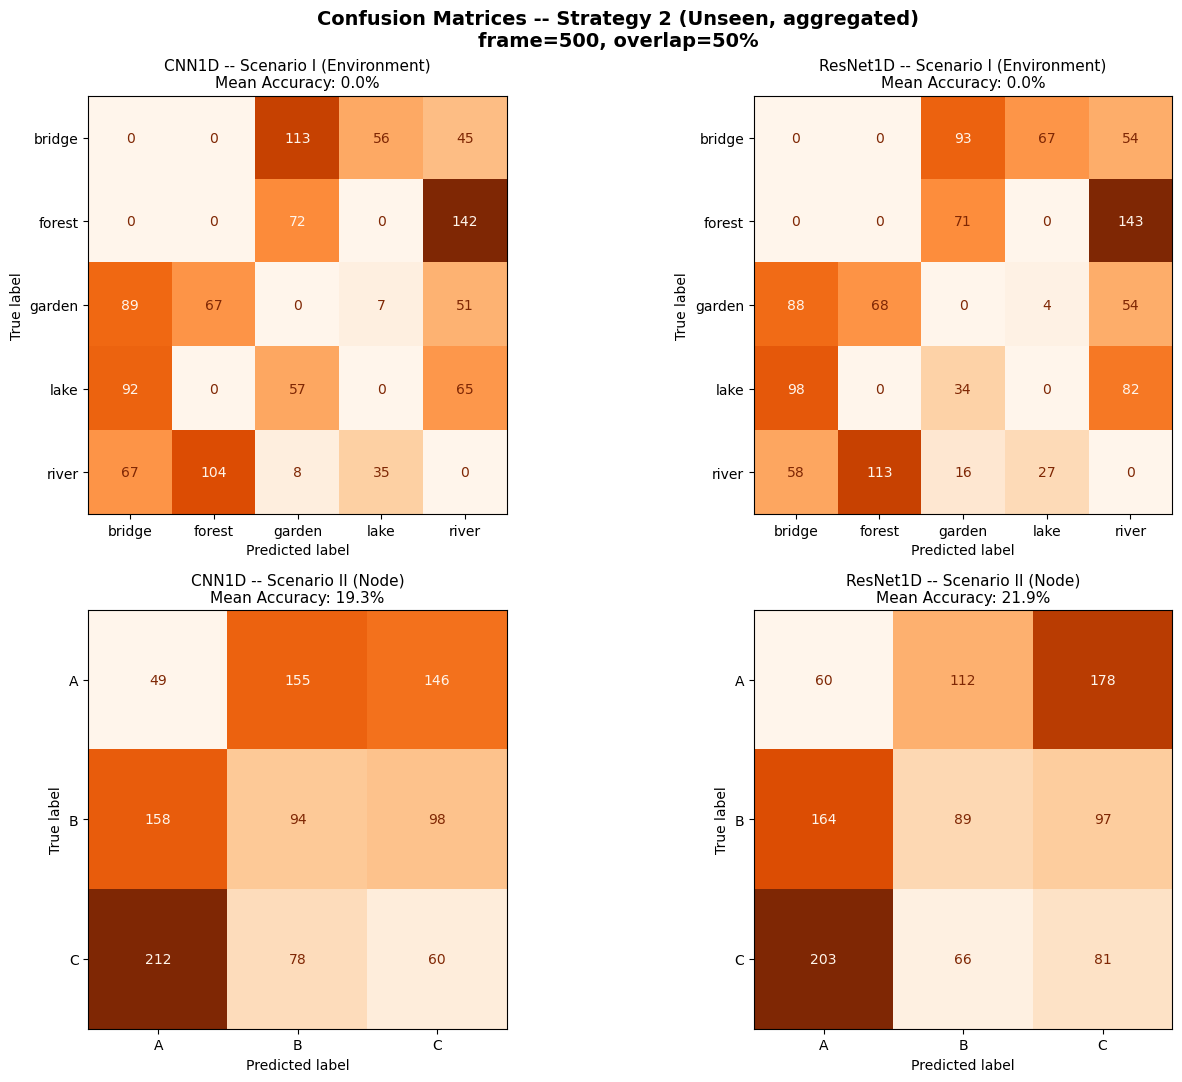

Saved -> confusion_matrices_strategy2_f500.png


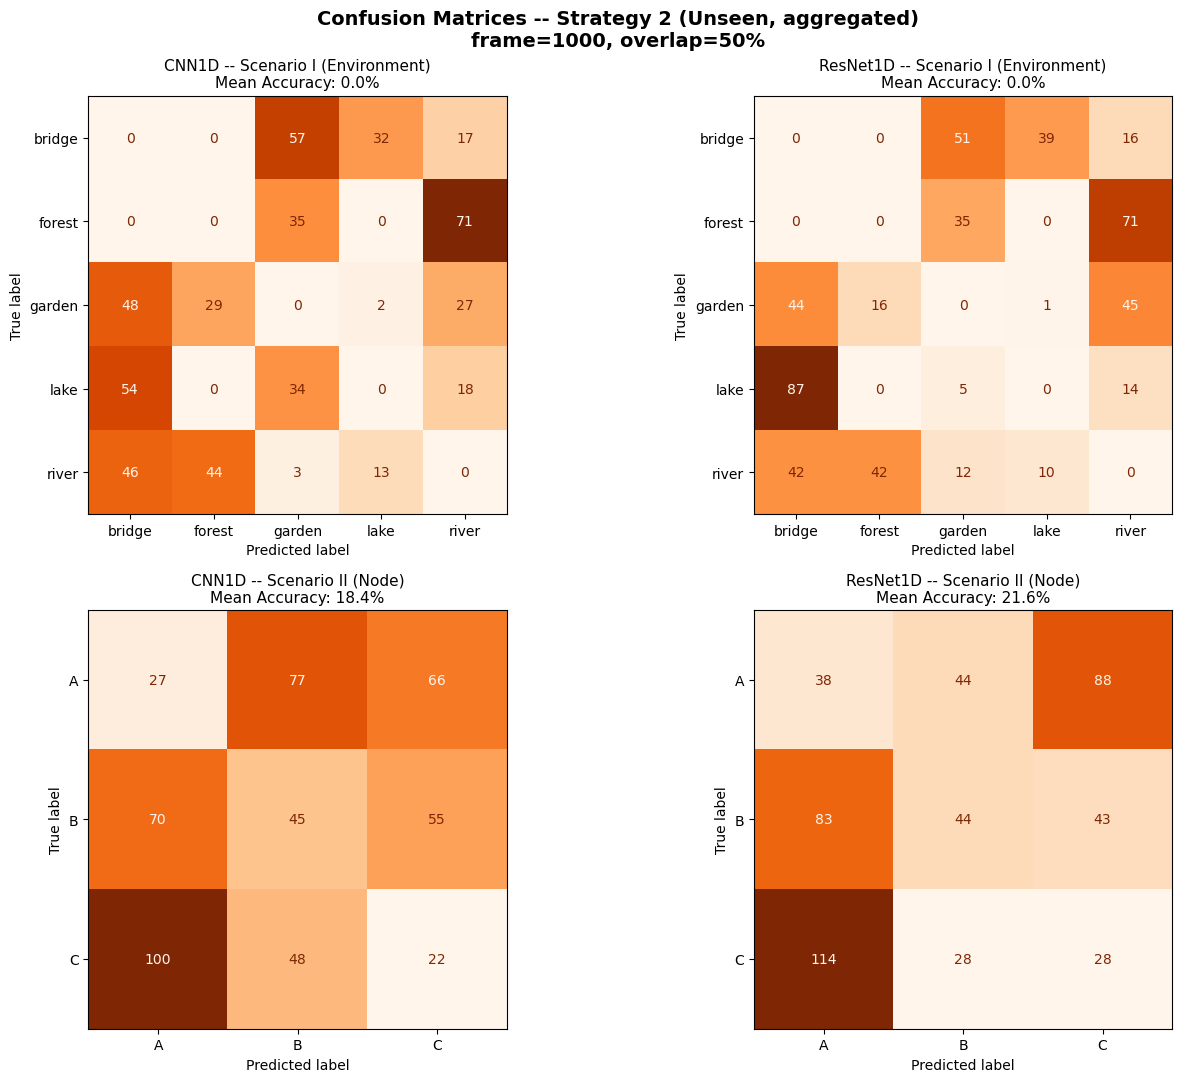

Saved -> confusion_matrices_strategy2_f1000.png


In [25]:
# Cell 10 – Confusion matrices: Strategy 2 (Unseen), BOTH frame sizes

for fs in [500, 1000]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"Confusion Matrices -- Strategy 2 (Unseen, aggregated)\n"
                 f"frame={fs}, overlap=50%", fontsize=14, fontweight="bold")

    for row, col, mname, scn_label in plot_configs:
        cm, labels, acc = cm_store[(mname, scn_label, "2 (Unseen)", fs, 0.5)]
        ax = axes[row][col]
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(
            ax=ax, cmap="Oranges", colorbar=False)
        ax.set_title(f"{mname} -- Scenario {scn_label}\n"
                     f"Mean Accuracy: {acc*100:.1f}%", fontsize=11)

    plt.tight_layout()
    plt.savefig(f"confusion_matrices_strategy2_f{fs}.png", dpi=150)
    plt.show()
    print(f"Saved -> confusion_matrices_strategy2_f{fs}.png")


In [26]:
# Cell 11 – Per-class accuracy breakdown (BOTH frame sizes, overlap=50%)

for fs in [500, 1000]:
    for strategy in ["1 (Seen)", "2 (Unseen)"]:
        print(f"\n{'='*65}")
        print(f"  STRATEGY {strategy} | frame={fs}")
        print(f"{'='*65}")
        for mname in ["CNN1D", "ResNet1D"]:
            for scn_label in ["I (Environment)", "II (Node)"]:
                cm, labels, acc = cm_store[(mname, scn_label, strategy, fs, 0.5)]
                row_sums = cm.sum(axis=1)
                per_class = np.where(row_sums > 0,
                                     cm.diagonal() / row_sums * 100, 0.0)
                print(f"\n  {mname} | Scenario {scn_label} | Overall: {acc*100:.1f}%")
                for lbl, pca, rs in zip(labels, per_class, row_sums):
                    print(f"    {lbl:>10s}: {pca:5.1f}%  (n={rs})")



  STRATEGY 1 (Seen) | frame=500

  CNN1D | Scenario I (Environment) | Overall: 83.6%
        bridge:  74.1%  (n=54)
        forest:  88.7%  (n=53)
        garden:  79.6%  (n=54)
          lake:  88.9%  (n=54)
         river:  86.8%  (n=53)

  CNN1D | Scenario II (Node) | Overall: 80.2%
             A:  79.3%  (n=87)
             B:  86.4%  (n=88)
             C:  75.0%  (n=88)

  ResNet1D | Scenario I (Environment) | Overall: 94.0%
        bridge:  90.7%  (n=54)
        forest: 100.0%  (n=53)
        garden:  92.6%  (n=54)
          lake:  88.9%  (n=54)
         river:  98.1%  (n=53)

  ResNet1D | Scenario II (Node) | Overall: 95.1%
             A:  94.3%  (n=87)
             B:  96.6%  (n=88)
             C:  94.3%  (n=88)

  STRATEGY 2 (Unseen) | frame=500

  CNN1D | Scenario I (Environment) | Overall: 0.0%
        bridge:   0.0%  (n=214)
        forest:   0.0%  (n=214)
        garden:   0.0%  (n=214)
          lake:   0.0%  (n=214)
         river:   0.0%  (n=214)

  CNN1D | Scenari

In [27]:
# Cell 12 – Summary comparison table (all 32 experiments)

results_df = pd.DataFrame(results)
print("=" * 90)
print("FULL RESULTS SUMMARY")
print("=" * 90)
print(results_df.to_string(index=False))


FULL RESULTS SUMMARY
   Model        Scenario   Strategy  Frame Overlap  Accuracy
   CNN1D I (Environment)   1 (Seen)    500     40%      90.2
   CNN1D I (Environment) 2 (Unseen)    500     40%       0.0
ResNet1D I (Environment)   1 (Seen)    500     40%      90.2
ResNet1D I (Environment) 2 (Unseen)    500     40%       0.0
   CNN1D I (Environment)   1 (Seen)    500     50%      83.6
   CNN1D I (Environment) 2 (Unseen)    500     50%       0.0
ResNet1D I (Environment)   1 (Seen)    500     50%      94.0
ResNet1D I (Environment) 2 (Unseen)    500     50%       0.0
   CNN1D I (Environment)   1 (Seen)   1000     40%      92.0
   CNN1D I (Environment) 2 (Unseen)   1000     40%       0.0
ResNet1D I (Environment)   1 (Seen)   1000     40%      93.8
ResNet1D I (Environment) 2 (Unseen)   1000     40%       0.0
   CNN1D I (Environment)   1 (Seen)   1000     50%      94.0
   CNN1D I (Environment) 2 (Unseen)   1000     50%       0.0
ResNet1D I (Environment)   1 (Seen)   1000     50%      95.5
Res

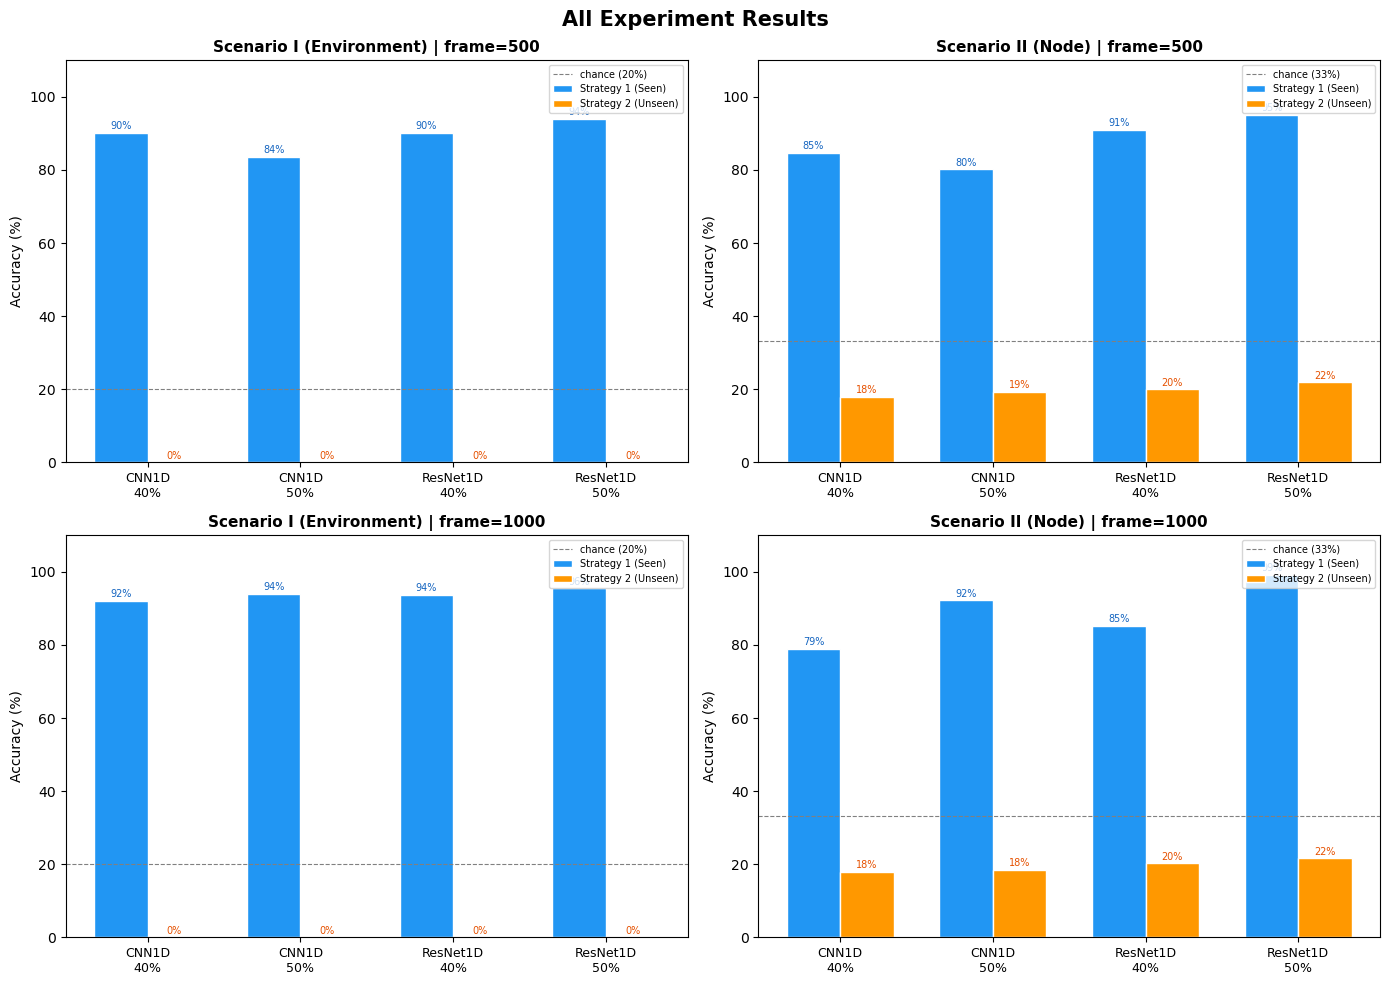

Saved -> results_comparison.png


In [28]:
# Cell 13 – Bar chart comparison (2x2 grid: frame x scenario, clean labels)

df = results_df.copy()
frames = sorted(df["Frame"].unique())
scenarios = df["Scenario"].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("All Experiment Results", fontsize=15, fontweight="bold")

for fi, fs in enumerate(frames):
    for si, scn in enumerate(scenarios):
        ax = axes[fi][si]
        sub = df[(df["Frame"] == fs) & (df["Scenario"] == scn)]

        groups = sub.groupby(["Model", "Overlap"]).agg(list).reset_index()
        n_groups = len(groups)
        x = np.arange(n_groups)
        width = 0.35

        s1_vals, s2_vals, labels = [], [], []
        for _, row in groups.iterrows():
            for j, strat in enumerate(row["Strategy"]):
                if "Seen" in strat and "Un" not in strat:
                    s1_vals.append(row["Accuracy"][j])
                else:
                    s2_vals.append(row["Accuracy"][j])
            labels.append(f"{row['Model']}\n{row['Overlap']}")

        ax.bar(x - width/2, s1_vals, width, label="Strategy 1 (Seen)",
               color="#2196F3", edgecolor="white")
        ax.bar(x + width/2, s2_vals, width, label="Strategy 2 (Unseen)",
               color="#FF9800", edgecolor="white")

        for i_bar, v in enumerate(s1_vals):
            ax.text(i_bar - width/2, v + 1, f"{v:.0f}%", ha="center",
                    fontsize=7, color="#1565C0")
        for i_bar, v in enumerate(s2_vals):
            ax.text(i_bar + width/2, v + 1, f"{v:.0f}%", ha="center",
                    fontsize=7, color="#E65100")

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel("Accuracy (%)")
        ax.set_title(f"Scenario {scn} | frame={fs}", fontsize=11, fontweight="bold")
        ax.set_ylim(0, 110)
        chance = 20 if "Environment" in scn else 33.3
        ax.axhline(y=chance, color="gray", ls="--", lw=0.8,
                   label=f"chance ({chance:.0f}%)")
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> results_comparison.png")


## Interpretation

| Scenario + Strategy | Expected | Why |
|---|---|---|
| **Scenario I, Strategy 1** | High accuracy | Models learn environment-specific signal patterns from the same distribution |
| **Scenario I, Strategy 2** | ~0% | Held-out environment was never seen during training — the model cannot predict it |
| **Scenario II, Strategy 1** | Moderate accuracy | Node SCR differences are subtle (realistic manufacturing variation), so classification is challenging |
| **Scenario II, Strategy 2** | Around or modestly above chance | The node fingerprint is present but weak — real hardware imperfections are small |

The near-zero Scenario I Strategy 2 accuracy confirms that environment fingerprints do not generalise.  
Any above-chance Scenario II Strategy 2 accuracy indicates that node hardware fingerprints persist across environments, even if the signal is subtle.
